# USD/INR Forecasting — Practical Demo

Real USD/INR market data → feature engineering → forecasting → model comparison → SHAP analysis.

**Data:** FRED EXINUS, monthly INR per USD, Jan 2015–Aug 2026.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, ElasticNetCV
import xgboost as xgb
import shap

pd.set_option("display.precision", 4)


/opt/pyvenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Real market data used in this project
dates = pd.date_range("2015-01-01", "2026-08-01", freq="MS")
values = [62.13, 61.9905, 62.4805, 62.6414, 63.715, 63.7809, 63.6045, 65.0971, 66.1667, 65.0262, 66.1, 66.5023, 67.3332, 68.2395, 66.8909, 66.4219, 66.8895, 67.2655, 67.158, 66.9035, 66.7138, 66.7415, 67.6395, 67.8052, 68.0474, 66.9726, 65.8009, 64.536, 64.4195, 64.4482, 64.424, 63.9683, 64.4775, 65.0357, 64.8435, 64.2445, 63.6452, 64.43, 65.0455, 65.6729, 67.51, 67.79, 68.6867, 69.6317, 72.2779, 73.5609, 71.738, 70.8331, 70.71, 71.1739, 69.4895, 69.4068, 69.7827, 69.388, 68.7391, 71.1891, 71.311, 71.0086, 71.4942, 71.1567, 71.279, 71.5295, 74.5482, 76.1682, 75.6575, 75.7077, 74.9286, 74.5657, 73.5233, 73.5648, 74.2311, 73.6195, 73.1106, 72.8053, 72.8196, 74.5186, 73.2065, 73.5782, 74.539, 74.1155, 73.6357, 74.92, 74.477, 75.3948, 74.4075, 74.9695, 76.1896, 76.1719, 77.2933, 78.09, 79.5915, 79.5065, 80.2538, 82.2915, 81.6805, 82.4738, 81.741, 82.5995, 82.2665, 81.9685, 82.2977, 82.2252, 82.1565, 82.8122, 83.07, 83.2162, 83.266, 83.254, 83.1119, 82.9485, 83.0214, 83.3968, 83.3873, 83.46, 83.5895, 83.8855, 83.791, 84.005, 84.3326, 84.9686, 86.2652, 87.0637, 86.5214, 85.5768, 85.2462, 85.8765, 86.1714, 87.5695, 88.3214, 88.3691, 88.8444, 90.035, 90.9025, 90.7458, 92.8182, 93.4805, 95.5335, 94.96, 95.8573, 95.4443]
df = pd.DataFrame({"date": dates, "USDINR": values})
df.tail()


,date,USDINR
135,2026-04-01,93.4805
136,2026-05-01,95.5335
137,2026-06-01,94.9600
138,2026-07-01,95.8573
139,2026-08-01,95.4443


## 1. Feature Engineering

Market-based predictors: `ret_1m`, `mom_3m`, `mom_6m`, `vol_3m`, `vol_6m`, `trend_12m`, `ma_gap_6m`, `drawdown_12m`.


In [3]:
FEATURES = ["ret_1m","mom_3m","mom_6m","vol_3m","vol_6m",
            "trend_12m","ma_gap_6m","drawdown_12m"]

df["ret_1m"] = 100*np.log(df.USDINR/df.USDINR.shift(1))
df["mom_3m"] = 100*np.log(df.USDINR/df.USDINR.shift(3))
df["mom_6m"] = 100*np.log(df.USDINR/df.USDINR.shift(6))
df["vol_3m"] = df["ret_1m"].rolling(3).std()
df["vol_6m"] = df["ret_1m"].rolling(6).std()
df["trend_12m"] = 100*np.log(df.USDINR/df.USDINR.shift(12))
df["ma_gap_6m"] = 100*(df.USDINR/df.USDINR.rolling(6).mean()-1)
df["drawdown_12m"] = 100*(df.USDINR/df.USDINR.rolling(12).max()-1)

for h in [3, 6]:
    df[f"target_h{h}"] = 100*np.log(df.USDINR.shift(-h)/df.USDINR)

df.dropna(subset=FEATURES).tail()


,date,USDINR,ret_1m,mom_3m,mom_6m,vol_3m,vol_6m,trend_12m,ma_gap_6m,drawdown_12m,target_h3,target_h6
135,2026-04-01,93.4805,0.7110,2.7965,5.6230,1.2303,0.8178,8.8339,2.5706,0.0000,2.5108,NaN
136,2026-05-01,95.5335,2.1724,5.1415,7.2590,0.8695,0.9233,11.3933,3.5564,0.0000,-0.0934,NaN
137,2026-06-01,94.9600,-0.6021,2.2813,5.3257,1.3879,1.1754,10.0546,2.0270,-0.6003,NaN,NaN
138,2026-07-01,95.8573,0.9405,2.5108,5.3073,1.3902,1.1752,10.6522,2.0853,0.0000,NaN,NaN
139,2026-08-01,95.4443,-0.4318,-0.0934,5.0481,0.8458,1.2256,8.6110,0.8048,-0.4308,NaN,NaN


## 2. Forecasting Models

- Random Walk benchmark
- Ridge
- Elastic Net
- XGBoost

An expanding-window out-of-sample test is used to avoid look-ahead bias.


In [4]:
def run_oos(h):
    target = f"target_h{h}"
    work = df.dropna(subset=FEATURES + [target]).copy()
    initial = pd.Timestamp("2019-12-01")
    rows, shap_rows = [], {}
    for dt in work.loc[work.date > initial, "date"]:
        tr = work[work.date < dt]
        te = work[work.date == dt]

        ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(tr[FEATURES], tr[target])
        enet = make_pipeline(
            StandardScaler(),
            ElasticNetCV(l1_ratio=[.1,.5,.9,1.0], alphas=50, cv=5,
                         max_iter=20000, random_state=42)
        ).fit(tr[FEATURES], tr[target])

        xgb_model = xgb.XGBRegressor(
            n_estimators=150, max_depth=2, learning_rate=.04,
            min_child_weight=4, subsample=.9, colsample_bytree=.9,
            reg_lambda=2, objective="reg:squarederror", random_state=42
        )
        xgb_model.fit(tr[FEATURES], tr[target], verbose=False)

        rows.append({
            "date": dt,
            "actual": te[target].iloc[0],
            "random_walk": 0.0,
            "ridge": ridge.predict(te[FEATURES])[0],
            "elastic_net": enet.predict(te[FEATURES])[0],
            "xgboost": xgb_model.predict(te[FEATURES])[0]
        })

        explainer = shap.TreeExplainer(xgb_model)
        sv = explainer.shap_values(tr[FEATURES])
        shap_rows[dt] = np.abs(sv).mean(axis=0)

    oos = pd.DataFrame(rows)
    shap_df = pd.DataFrame(shap_rows, index=FEATURES).T
    return oos, shap_df

oos3, shap3 = run_oos(3)
oos6, shap6 = run_oos(6)
print("3-month forecasts:", len(oos3))
print("6-month forecasts:", len(oos6))


3-month forecasts: 77
6-month forecasts: 74


In [5]:
def accuracy(oos):
    result = []
    for model in ["random_walk","ridge","elastic_net","xgboost"]:
        e = oos["actual"] - oos[model]
        result.append({
            "Model": model,
            "RMSE (%)": np.sqrt(np.mean(e**2)),
            "MAE (%)": np.mean(np.abs(e)),
            "Direction Accuracy (%)": np.nan if model=="random_walk"
                else 100*np.mean(np.sign(oos.actual)==np.sign(oos[model]))
        })
    return pd.DataFrame(result)

print("=== 3-month horizon ===")
display(accuracy(oos3))
print("=== 6-month horizon ===")
display(accuracy(oos6))


=== 3-month horizon ===


,Model,RMSE (%),MAE (%),Direction Accuracy (%)
0,random_walk,2.0609,1.5548,NaN
1,ridge,1.7797,1.4411,76.6234
2,elastic_net,1.8102,1.3673,74.0260
3,xgboost,1.8634,1.4704,77.9221


=== 6-month horizon ===


,Model,RMSE (%),MAE (%),Direction Accuracy (%)
0,random_walk,3.1632,2.4671,NaN
1,ridge,2.7050,2.2001,78.3784
2,elastic_net,2.5648,2.0026,81.0811
3,xgboost,2.5001,1.9501,79.7297


In [6]:
print("Mean absolute SHAP importance — 3M")
display(shap3.mean().sort_values(ascending=False).to_frame("mean_abs_shap"))

print("Mean absolute SHAP importance — 6M")
display(shap6.mean().sort_values(ascending=False).to_frame("mean_abs_shap"))


Mean absolute SHAP importance — 3M


,mean_abs_shap
trend_12m,0.7014
drawdown_12m,0.5369
vol_6m,0.2873
mom_6m,0.2381
mom_3m,0.2166
ma_gap_6m,0.1928
vol_3m,0.1784
ret_1m,0.0982


Mean absolute SHAP importance — 6M


,mean_abs_shap
trend_12m,1.1884
vol_6m,0.6856
drawdown_12m,0.6622
ret_1m,0.3107
mom_6m,0.3002
mom_3m,0.1836
ma_gap_6m,0.1253
vol_3m,0.0875


## 3. Output and Analysis

The next cells give the model metrics, graphs and SHAP feature importance. These are the main outputs to show during the faculty demonstration.


In [7]:
# Final model using all available observations through Aug 2026
latest = df.dropna(subset=FEATURES).tail(1)

def final_forecast(h):
    target = f"target_h{h}"
    train = df.dropna(subset=FEATURES+[target])
    ridge = make_pipeline(StandardScaler(), Ridge(alpha=1.0)).fit(train[FEATURES], train[target])
    enet = make_pipeline(
        StandardScaler(),
        ElasticNetCV(l1_ratio=[.1,.5,.9,1.0], alphas=50, cv=5,
                     max_iter=20000, random_state=42)
    ).fit(train[FEATURES], train[target])
    model = xgb.XGBRegressor(
        n_estimators=150, max_depth=2, learning_rate=.04,
        min_child_weight=4, subsample=.9, colsample_bytree=.9,
        reg_lambda=2, objective="reg:squarederror", random_state=42
    )
    model.fit(train[FEATURES], train[target], verbose=False)

    preds = {
        "Ridge": ridge.predict(latest[FEATURES])[0],
        "Elastic Net": enet.predict(latest[FEATURES])[0],
        "XGBoost": model.predict(latest[FEATURES])[0]
    }
    rate_forecasts = {k: latest.USDINR.iloc[0]*np.exp(v/100) for k,v in preds.items()}
    return preds, rate_forecasts

for h in [3,6]:
    ret, rate = final_forecast(h)
    print(f"{h}-month forward return forecast:", ret)
    print(f"{h}-month implied USD/INR:", rate)


3-month forward return forecast: {'Ridge': np.float64(0.3846105057479024), 'Elastic Net': np.float64(0.6929897637254925), 'XGBoost': np.float32(0.85819936)}
3-month implied USD/INR: {'Ridge': np.float64(95.81209564189136), 'Elastic Net': np.float64(96.10801631596246), 'XGBoost': np.float64(96.26692973002196)}


6-month forward return forecast: {'Ridge': np.float64(0.12011580553628254), 'Elastic Net': np.float64(1.6879307708914302), 'XGBoost': np.float32(0.6706311)}
6-month implied USD/INR: {'Ridge': np.float64(95.5590125699551), 'Elastic Net': np.float64(97.06900709973412), 'XGBoost': np.float64(96.08653396275044)}


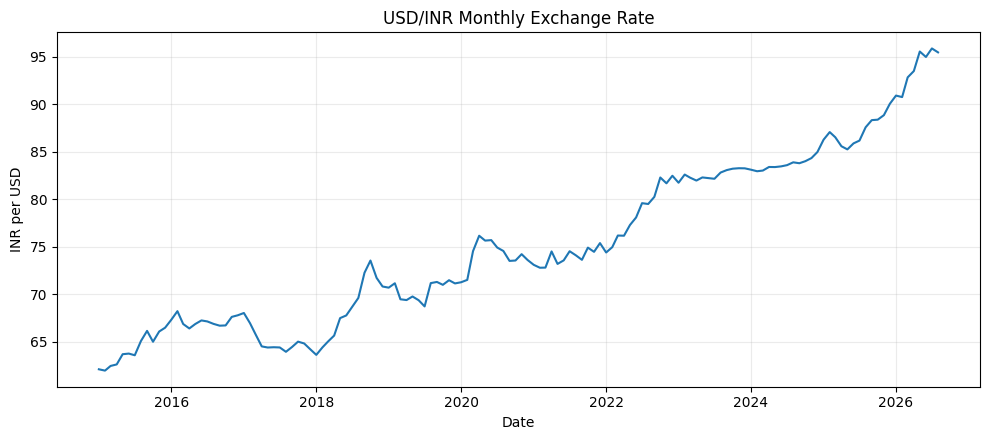

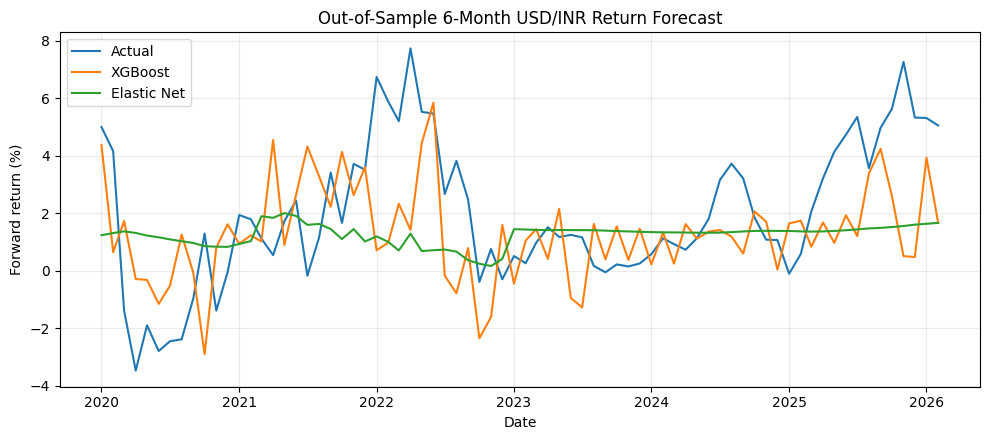

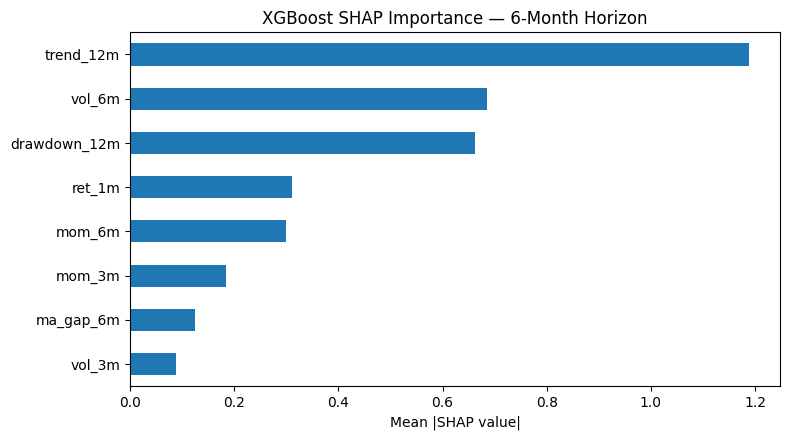

In [8]:
# Historical USD/INR chart
plt.figure(figsize=(10,4.5))
plt.plot(df.date, df.USDINR)
plt.title("USD/INR Monthly Exchange Rate")
plt.xlabel("Date"); plt.ylabel("INR per USD")
plt.grid(alpha=.25)
plt.tight_layout()
plt.show()

# 6M OOS forecast comparison
plt.figure(figsize=(10,4.5))
plt.plot(oos6.date, oos6.actual, label="Actual")
plt.plot(oos6.date, oos6.xgboost, label="XGBoost")
plt.plot(oos6.date, oos6.elastic_net, label="Elastic Net")
plt.title("Out-of-Sample 6-Month USD/INR Return Forecast")
plt.xlabel("Date"); plt.ylabel("Forward return (%)")
plt.legend(); plt.grid(alpha=.25)
plt.tight_layout()
plt.show()

# SHAP ranking
shap6.mean().sort_values().plot(kind="barh", figsize=(8,4.5))
plt.title("XGBoost SHAP Importance — 6-Month Horizon")
plt.xlabel("Mean |SHAP value|")
plt.tight_layout()
plt.show()


In [12]:
# Final values 
latest_rate = df.USDINR.iloc[-1]
ret3, rate3 = final_forecast(3)
ret6, rate6 = final_forecast(6)
print("Latest monthly USD/INR:", round(latest_rate, 4))
print("3M XGBoost forecast:", round(ret3["XGBoost"], 3), "%")
print("3M implied USD/INR:", round(rate3["XGBoost"], 2))
print("6M XGBoost forecast:", round(ret6["XGBoost"], 3), "%")
print("6M implied USD/INR:", round(rate6["XGBoost"], 2))


Latest monthly USD/INR: 95.4443
3M XGBoost forecast: 0.858 %
3M implied USD/INR: 96.27
6M XGBoost forecast: 0.671 %
6M implied USD/INR: 96.09
